In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df1 = pd.read_csv("train (1).csv")
df2 = pd.read_csv("test (1).csv")

In [3]:
df1["source"] = "df1"
df2["source"] = "df2"

df = pd.concat([df1, df2], ignore_index=True)

In [4]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,source
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,df1
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,df1
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,df1
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,df1
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,df1


In [5]:
df.isnull().sum()


id                       0
age                      0
gender                   0
course                   0
study_hours              0
class_attendance         0
internet_access          0
sleep_hours              0
sleep_quality            0
study_method             0
facility_rating          0
exam_difficulty          0
exam_score          270000
source                   0
dtype: int64

In [6]:
df.shape

(900000, 14)

In [7]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,900000.000000,900000.000000,900000.000000,900000.000000,900000.000000,630000.000000
mean,449999.500000,20.545316,4.002800,71.985836,7.072552,62.506672
std,259807.765473,2.260301,2.359238,17.425469,1.745021,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,224999.750000,19.000000,1.980000,57.000000,5.600000,48.800000
50%,449999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,674999.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,899999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [8]:
df["sleep_quality"].value_counts()

sleep_quality
poor       305355
good       304843
average    289802
Name: count, dtype: int64

In [9]:
df["course"].value_counts()

course
b.tech     187697
b.sc       159266
b.com      158267
bca        126810
bba        107743
ba          88863
diploma     71354
Name: count, dtype: int64

In [10]:
df["study_method"].value_counts()

study_method
coaching         188395
self-study       187072
group study      175789
mixed            175778
online videos    172966
Name: count, dtype: int64

In [11]:
df["facility_rating"].value_counts()

facility_rating
medium    305898
low       303700
high      290402
Name: count, dtype: int64

In [12]:
df["discipline_score"] = (
    0.4 * df["study_hours"] +
    0.4 * df["class_attendance"] / 100 +
    0.2 * (df["study_method"] == "self-study").astype(int)
)



In [13]:
sleep_quality_map = {"poor": 0, "average": 0.5, "good": 1}
df["sleep_quality_num"] = df["sleep_quality"].map(sleep_quality_map)

df["sleep_health"] = (
    df["sleep_hours"] / 8 * df["sleep_quality_num"]
)


In [14]:
difficulty_map = {"easy": 0.5, "moderate": 1, "hard": 1.5}
df["exam_difficulty_num"] = df["exam_difficulty"].map(difficulty_map)

df["stress_index"] = df["exam_difficulty_num"] * (1 - df["sleep_health"])


In [15]:
import numpy as np

df["log_study_hours"] = np.log1p(df["study_hours"])
df["attendance_sq"] = df["class_attendance"] ** 2


In [16]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,...,exam_difficulty,exam_score,source,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,stress_index,log_study_hours,attendance_sq
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,...,easy,78.3,df1,3.5592,0.5,0.30625,0.5,0.346875,2.187174,9761.44
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,...,moderate,46.7,df1,2.5592,0.0,0.00000,1.0,1.000000,1.783391,8987.04
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,...,moderate,99.0,df1,2.2424,0.0,0.00000,1.0,1.000000,1.736951,8574.76
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,...,moderate,63.9,df1,0.9980,0.5,0.51875,1.0,0.481250,1.098612,2450.25
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,...,easy,100.0,df1,3.6076,1.0,1.20000,0.5,-0.100000,2.157559,7551.61


In [17]:
df["exam_difficulty_num"].value_counts()

exam_difficulty_num
1.0    505638
0.5    252171
1.5    142191
Name: count, dtype: int64

In [18]:
sleep_map = {"poor": 0, "average": 1, "good": 2}
difficulty_map = {"easy": 0, "moderate": 1, "hard": 2}

df["sleep_quality_enc"] = df["sleep_quality"].map(sleep_map)
df["exam_difficulty_enc"] = df["exam_difficulty"].map(difficulty_map)


In [19]:
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

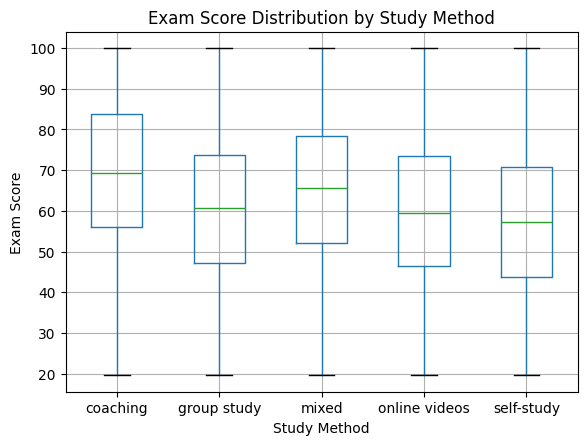

In [20]:
plt.figure()
df.boxplot(column="exam_score", by="study_method")
plt.xlabel("Study Method")
plt.ylabel("Exam Score")
plt.title("Exam Score Distribution by Study Method")
plt.suptitle("")  # remove extra pandas title
plt.show()

In [21]:
from sklearn.preprocessing import OneHotEncoder



In [22]:
ohe = OneHotEncoder(
    drop="first",        # same as drop_first=True
    sparse_output=False,        # return NumPy array (easier to work with)
    dtype=int            # 🔥 converts True/False → 1/0 automatically
)


In [23]:
cat_cols = ["study_method", "gender", "course", "internet_access"]


In [24]:
encoded_array = ohe.fit_transform(df[cat_cols])


In [26]:
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)


In [27]:
encoded_df.head()

,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes
0,0,0,1,0,0,0,1,0,0,0,0,0,0
1,0,0,0,1,0,1,0,0,0,0,0,1,1
2,0,0,0,0,0,0,1,0,0,0,0,0,1
3,1,0,0,0,1,0,1,0,0,0,0,0,1
4,0,0,0,1,1,0,0,0,0,0,1,0,1


In [28]:
df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)


In [29]:
df.shape

(900000, 32)

In [30]:
df.head()

,id,age,study_hours,class_attendance,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score,source,...,study_method_self-study,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes
0,0,21,7.91,98.8,4.9,average,low,easy,78.3,df1,...,0,0,0,1,0,0,0,0,0,0
1,1,18,4.95,94.8,4.7,poor,medium,moderate,46.7,df1,...,1,0,1,0,0,0,0,0,1,1
2,2,20,4.68,92.6,5.8,poor,high,moderate,99.0,df1,...,0,0,0,1,0,0,0,0,0,1
3,3,19,2.00,49.5,8.3,average,high,moderate,63.9,df1,...,0,1,0,1,0,0,0,0,0,1
4,4,23,7.65,86.9,9.6,good,high,easy,100.0,df1,...,1,1,0,0,0,0,0,1,0,1


In [31]:
df.isnull().sum()

id                                 0
age                                0
study_hours                        0
class_attendance                   0
sleep_hours                        0
sleep_quality                      0
facility_rating                    0
exam_difficulty                    0
exam_score                    270000
source                             0
discipline_score                   0
sleep_quality_num                  0
sleep_health                       0
exam_difficulty_num                0
stress_index                       0
log_study_hours                    0
attendance_sq                      0
sleep_quality_enc                  0
exam_difficulty_enc                0
study_method_group study           0
study_method_mixed                 0
study_method_online videos         0
study_method_self-study            0
gender_male                        0
gender_other                       0
course_b.sc                        0
course_b.tech                      0
c

In [32]:
df["facility_rating"].unique()


array(['low', 'medium', 'high'], dtype=object)

In [33]:
facility_map = {
    "low": 1,
    "medium": 2,
    "high": 3
}

df["facility_rating_num"] = df["facility_rating"].map(facility_map)


In [34]:
df.head()

,id,age,study_hours,class_attendance,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score,source,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
0,0,21,7.91,98.8,4.9,average,low,easy,78.3,df1,...,0,0,1,0,0,0,0,0,0,1
1,1,18,4.95,94.8,4.7,poor,medium,moderate,46.7,df1,...,0,1,0,0,0,0,0,1,1,2
2,2,20,4.68,92.6,5.8,poor,high,moderate,99.0,df1,...,0,0,1,0,0,0,0,0,1,3
3,3,19,2.00,49.5,8.3,average,high,moderate,63.9,df1,...,1,0,1,0,0,0,0,0,1,3
4,4,23,7.65,86.9,9.6,good,high,easy,100.0,df1,...,1,0,0,0,0,0,1,0,1,3


In [35]:
df.drop(columns=["sleep_quality","facility_rating","exam_difficulty"],inplace=True)

In [36]:
num_cols = [
    "age",
    "study_hours",
    "sleep_hours",
    "class_attendance",
    "facility_rating",
    "exam_score"
]


In [37]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


In [38]:
outliers, low, high = detect_outliers_iqr(df, "study_hours")
print(f"Outliers count: {len(outliers)}")
print(f"Bounds: {low} to {high}")


Outliers count: 0
Bounds: -4.125 to 12.155000000000001


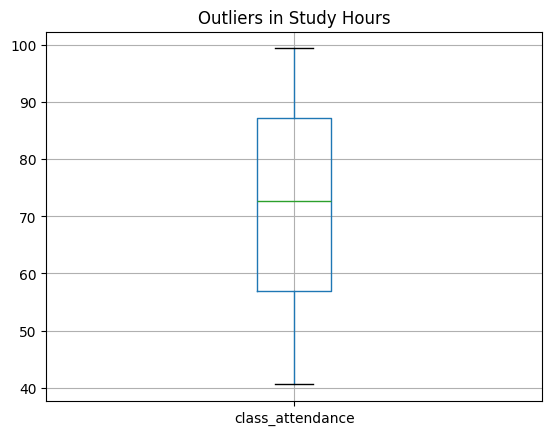

In [39]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="class_attendance")
plt.title("Outliers in Study Hours")
plt.show()


In [40]:
num_cols = [
    "age",
    "study_hours",
    "sleep_hours",
    "class_attendance",
    "facility_rating_num"
]


In [41]:
df.head()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,source,discipline_score,sleep_quality_num,sleep_health,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
0,0,21,7.91,98.8,4.9,78.3,df1,3.5592,0.5,0.30625,...,0,0,1,0,0,0,0,0,0,1
1,1,18,4.95,94.8,4.7,46.7,df1,2.5592,0.0,0.00000,...,0,1,0,0,0,0,0,1,1,2
2,2,20,4.68,92.6,5.8,99.0,df1,2.2424,0.0,0.00000,...,0,0,1,0,0,0,0,0,1,3
3,3,19,2.00,49.5,8.3,63.9,df1,0.9980,0.5,0.51875,...,1,0,1,0,0,0,0,0,1,3
4,4,23,7.65,86.9,9.6,100.0,df1,3.6076,1.0,1.20000,...,1,0,0,0,0,0,1,0,1,3


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[num_cols])


In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # keep 95% variance
X_num_pca = pca.fit_transform(X_num_scaled)


In [44]:
pca_cols = [f"PCA_{i+1}" for i in range(X_num_pca.shape[1])]
df_pca = pd.DataFrame(X_num_pca, columns=pca_cols, index=df.index)


In [45]:
df_final = pd.concat(
    [
        df.drop(columns=num_cols + ["exam_score"]),
        df_pca,
        df["exam_score"]
    ],
    axis=1
)


In [46]:
print(pca.explained_variance_ratio_)
print("Total variance:", pca.explained_variance_ratio_.sum())


[0.22486503 0.20064075 0.1994099  0.19290525 0.18217907]
Total variance: 1.0


In [47]:
df.head()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,source,discipline_score,sleep_quality_num,sleep_health,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
0,0,21,7.91,98.8,4.9,78.3,df1,3.5592,0.5,0.30625,...,0,0,1,0,0,0,0,0,0,1
1,1,18,4.95,94.8,4.7,46.7,df1,2.5592,0.0,0.00000,...,0,1,0,0,0,0,0,1,1,2
2,2,20,4.68,92.6,5.8,99.0,df1,2.2424,0.0,0.00000,...,0,0,1,0,0,0,0,0,1,3
3,3,19,2.00,49.5,8.3,63.9,df1,0.9980,0.5,0.51875,...,1,0,1,0,0,0,0,0,1,3
4,4,23,7.65,86.9,9.6,100.0,df1,3.6076,1.0,1.20000,...,1,0,0,0,0,0,1,0,1,3


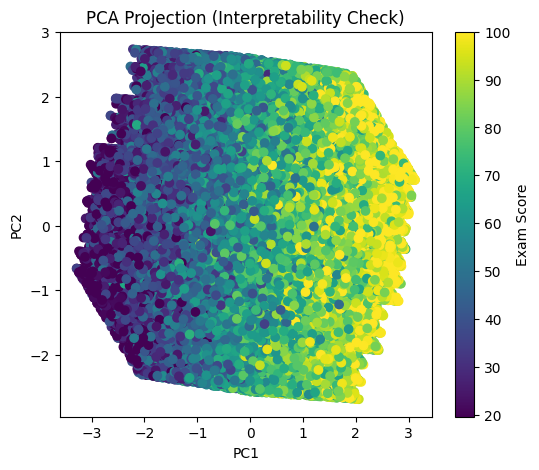

In [48]:
import matplotlib.pyplot as plt

pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["exam_score"], cmap="viridis")
plt.colorbar(label="Exam Score")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Interpretability Check)")
plt.show()


In [49]:
df1_back = df[df["source"] == "df1"]
df2_back = df[df["source"] == "df2"]

In [50]:
df1_back.shape

(630000, 30)

In [51]:
df1_back.drop(columns=["source"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\4148944438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_back.drop(columns=["source"],inplace=True)


In [52]:
df1_back.corr()["exam_score"].sort_values(ascending=False)

exam_score                    1.000000
discipline_score              0.770549
study_hours                   0.762267
log_study_hours               0.735245
class_attendance              0.360954
attendance_sq                 0.357263
sleep_health                  0.264546
sleep_quality_num             0.236895
sleep_quality_enc             0.236895
facility_rating_num           0.188159
sleep_hours                   0.167410
study_method_mixed            0.067598
course_bba                    0.014164
age                           0.010472
gender_other                  0.010302
exam_difficulty_num           0.008773
exam_difficulty_enc           0.008773
course_bca                    0.001703
internet_access_yes           0.000447
id                            0.000372
course_b.tech                 0.000353
course_diploma               -0.001587
course_b.sc                  -0.005178
course_ba                    -0.010823
gender_male                  -0.012403
study_method_group study 

In [53]:
df1_back.drop(columns=[
    "log_study_hours",
    "sleep_quality_enc",
    "exam_difficulty_enc",
    "attendance_sq"
],inplace=True)


C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\4156622226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_back.drop(columns=[


In [54]:
df1_back.drop(columns=[
    "id"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\1026540162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_back.drop(columns=[


In [55]:
df1_back.head()

,age,study_hours,class_attendance,sleep_hours,exam_score,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,stress_index,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
0,21,7.91,98.8,4.9,78.3,3.5592,0.5,0.30625,0.5,0.346875,...,0,0,1,0,0,0,0,0,0,1
1,18,4.95,94.8,4.7,46.7,2.5592,0.0,0.00000,1.0,1.000000,...,0,1,0,0,0,0,0,1,1,2
2,20,4.68,92.6,5.8,99.0,2.2424,0.0,0.00000,1.0,1.000000,...,0,0,1,0,0,0,0,0,1,3
3,19,2.00,49.5,8.3,63.9,0.9980,0.5,0.51875,1.0,0.481250,...,1,0,1,0,0,0,0,0,1,3
4,23,7.65,86.9,9.6,100.0,3.6076,1.0,1.20000,0.5,-0.100000,...,1,0,0,0,0,0,1,0,1,3


In [ ]:
X = df1_back.drop("exam_score", axis=1)
y = df1_back["exam_score"]


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


In [58]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

print("Baseline R²:", baseline.score(X_val, y_val))


Baseline R²: -1.6731591339080865e-06


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)  

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)


discipline_score              0.601233
class_attendance              0.109719
sleep_health                  0.060097
study_hours                   0.054619
sleep_hours                   0.030361
facility_rating_num           0.026174
stress_index                  0.022852
age                           0.019509
study_method_self-study       0.012590
study_method_online videos    0.008835
dtype: float64

In [60]:
import lightgbm as lgb
from lightgbm import early_stopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define the model
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    random_state=42
)

# Train the model with early stopping
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[early_stopping(stopping_rounds=50)]
    
)

# Get best iteration
best_iter = lgb_model.best_iteration_
print(f"Best iteration: {best_iter}")

# Predict on validation set
y_pred = lgb_model.predict(X_val, num_iteration=best_iter)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1226
[LightGBM] [Info] Number of data points in the train set: 441000, number of used features: 23
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 62.484815
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 8.77797	valid_0's l2: 77.0527
Best iteration: 1000
Validation RMSE: 8.7780
Validation MAE: 7.0079


In [61]:
df2_back.drop(columns=[
    "log_study_hours",
    "sleep_quality_enc",
    "exam_difficulty_enc",
    "attendance_sq"
],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\2375671097.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back.drop(columns=[


In [62]:
df2_back.drop(columns=["id"
],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\1049782011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back.drop(columns=["id"


In [67]:
df1_back.shape

(630000, 24)

In [69]:
df2_back.head()

,age,study_hours,class_attendance,sleep_hours,exam_score,source,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
630000,24,6.85,65.2,5.2,NaN,df2,3.0008,0.0,0.00000,0.5,...,0,1,0,0,1,0,0,0,1,3
630001,18,6.61,45.0,9.3,NaN,df2,2.8240,0.0,0.00000,0.5,...,1,0,0,0,0,0,0,1,0,1
630002,24,6.60,98.5,6.2,NaN,df2,3.0340,1.0,0.77500,1.0,...,0,0,0,1,0,0,0,0,1,2
630003,24,3.03,66.3,5.7,NaN,df2,1.4772,0.5,0.35625,1.0,...,1,0,0,0,0,0,0,1,1,2
630004,20,2.03,42.4,9.2,NaN,df2,0.9816,0.5,0.57500,1.0,...,0,0,0,1,0,0,0,0,1,1


In [70]:
df2_back.drop(columns=["source","exam_score"],inplace=True)

C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\3804525146.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back.drop(columns=["source","exam_score"],inplace=True)


In [65]:
X_full = df1_back.drop("exam_score", axis=1)
y_full = df1_back["exam_score"]



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1200
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 23
[LightGBM] [Info] Start training from score 62.506672
Full data RMSE (just for reference): 8.7052
Full data MAE (just for reference): 6.9458


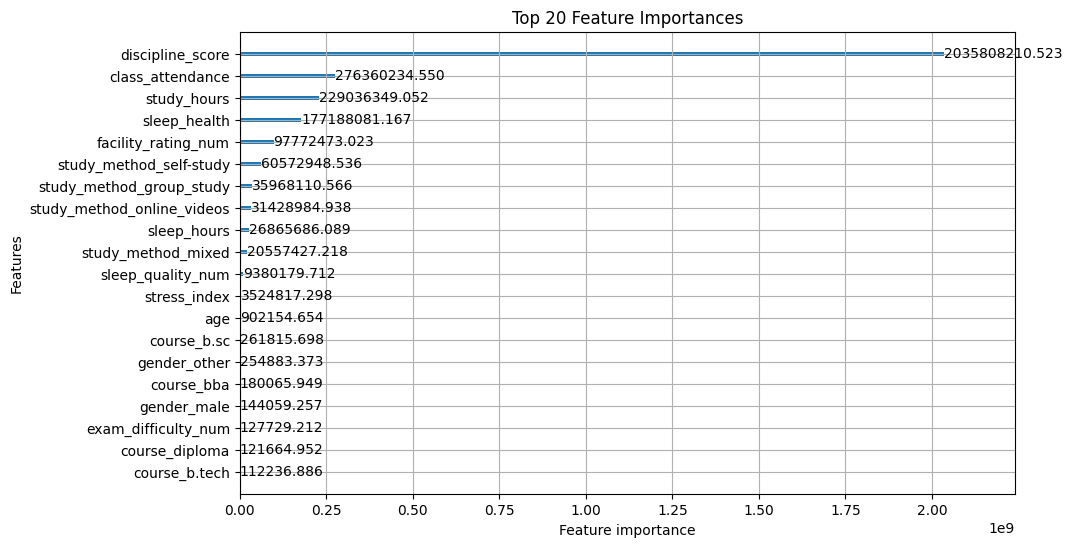

In [66]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define the model
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    random_state=42
)

# Train the model on the full dataset
lgb_model.fit(
    X_full,  # Your full feature matrix
    y_full,  # Your target vector (exam_score)
    eval_metric="rmse",  # Optional, will print warnings if no eval_set
    callbacks=[lgb.log_evaluation(period=0)]  # Suppress logs
)

# Predict on the same dataset (optional)
y_pred = lgb_model.predict(X_full)

# Evaluate performance on the full data (just for reference)
rmse = np.sqrt(mean_squared_error(y_full, y_pred))
mae = mean_absolute_error(y_full, y_pred)

print(f"Full data RMSE (just for reference): {rmse:.4f}")
print(f"Full data MAE (just for reference): {mae:.4f}")

# Feature importance (optional)
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20, importance_type='gain', figsize=(10,6))
plt.title("Top 20 Feature Importances")
plt.show()


In [71]:
df2_back.head()

,age,study_hours,class_attendance,sleep_hours,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,stress_index,study_method_group study,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
630000,24,6.85,65.2,5.2,3.0008,0.0,0.00000,0.5,0.50000,1,...,0,1,0,0,1,0,0,0,1,3
630001,18,6.61,45.0,9.3,2.8240,0.0,0.00000,0.5,0.50000,0,...,1,0,0,0,0,0,0,1,0,1
630002,24,6.60,98.5,6.2,3.0340,1.0,0.77500,1.0,0.22500,1,...,0,0,0,1,0,0,0,0,1,2
630003,24,3.03,66.3,5.7,1.4772,0.5,0.35625,1.0,0.64375,0,...,1,0,0,0,0,0,0,1,1,2
630004,20,2.03,42.4,9.2,0.9816,0.5,0.57500,1.0,0.42500,0,...,0,0,0,1,0,0,0,0,1,1


In [73]:
X_test = df2_back

In [74]:
# Ensure same column order
X_test = X_test[X_full.columns]

# Check for missing columns
missing_cols = set(X_full.columns) - set(X_test.columns)
print("Missing columns:", missing_cols)


Missing columns: set()


In [75]:
test_predictions = lgb_model.predict(X_test)


In [76]:
df2_back["predicted_exam_score"] = test_predictions
df2_back.head()


C:\Users\YASH PRABAKAR KATE\AppData\Local\Temp\ipykernel_10996\558908134.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_back["predicted_exam_score"] = test_predictions


,age,study_hours,class_attendance,sleep_hours,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,stress_index,study_method_group study,...,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num,predicted_exam_score
630000,24,6.85,65.2,5.2,3.0008,0.0,0.00000,0.5,0.50000,1,...,1,0,0,1,0,0,0,1,3,71.644071
630001,18,6.61,45.0,9.3,2.8240,0.0,0.00000,0.5,0.50000,0,...,0,0,0,0,0,0,1,0,1,70.022708
630002,24,6.60,98.5,6.2,3.0340,1.0,0.77500,1.0,0.22500,1,...,0,0,1,0,0,0,0,1,2,87.507960
630003,24,3.03,66.3,5.7,1.4772,0.5,0.35625,1.0,0.64375,0,...,0,0,0,0,0,0,1,1,2,56.113739
630004,20,2.03,42.4,9.2,0.9816,0.5,0.57500,1.0,0.42500,0,...,0,0,1,0,0,0,0,1,1,47.376219


In [77]:
df2_back.to_csv("exam_score_predictions.csv", index=False)
print("Predictions saved successfully.")


Predictions saved successfully.


In [78]:
df2.head()


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,source
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy,df2
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy,df2
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate,df2
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate,df2
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate,df2


In [79]:
df2.to_csv("exam_score_predictions(1).csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.


In [80]:
df2["predicted_exam_score"] = test_predictions
df2.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,source,predicted_exam_score
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy,df2,71.644071
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy,df2,70.022708
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate,df2,87.507960
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate,df2,56.113739
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate,df2,47.376219


In [82]:
df2.drop(columns=["source"],inplace=True)

In [83]:
df2.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,predicted_exam_score
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy,71.644071
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy,70.022708
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate,87.507960
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate,56.113739
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate,47.376219


In [84]:
df2.to_csv("exam_score_predictions(2).csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.


In [85]:
df2_back.head()

,age,study_hours,class_attendance,sleep_hours,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,stress_index,study_method_group study,...,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num,predicted_exam_score
630000,24,6.85,65.2,5.2,3.0008,0.0,0.00000,0.5,0.50000,1,...,1,0,0,1,0,0,0,1,3,71.644071
630001,18,6.61,45.0,9.3,2.8240,0.0,0.00000,0.5,0.50000,0,...,0,0,0,0,0,0,1,0,1,70.022708
630002,24,6.60,98.5,6.2,3.0340,1.0,0.77500,1.0,0.22500,1,...,0,0,1,0,0,0,0,1,2,87.507960
630003,24,3.03,66.3,5.7,1.4772,0.5,0.35625,1.0,0.64375,0,...,0,0,0,0,0,0,1,1,2,56.113739
630004,20,2.03,42.4,9.2,0.9816,0.5,0.57500,1.0,0.42500,0,...,0,0,1,0,0,0,0,1,1,47.376219


In [87]:
df2_result = df2.loc[:, ["id", "predicted_exam_score"]]


In [88]:
df2_result.to_csv("exam_score_predictions(2).csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.


In [89]:
df2_result.rename(columns={"predicted_exam_score": "exam_score"}, inplace=True)


In [90]:
df2_result.to_csv("exam_score_predictions(3).csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.


In [91]:
df1_back.head()

,age,study_hours,class_attendance,sleep_hours,exam_score,discipline_score,sleep_quality_num,sleep_health,exam_difficulty_num,stress_index,...,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,facility_rating_num
0,21,7.91,98.8,4.9,78.3,3.5592,0.5,0.30625,0.5,0.346875,...,0,0,1,0,0,0,0,0,0,1
1,18,4.95,94.8,4.7,46.7,2.5592,0.0,0.00000,1.0,1.000000,...,0,1,0,0,0,0,0,1,1,2
2,20,4.68,92.6,5.8,99.0,2.2424,0.0,0.00000,1.0,1.000000,...,0,0,1,0,0,0,0,0,1,3
3,19,2.00,49.5,8.3,63.9,0.9980,0.5,0.51875,1.0,0.481250,...,1,0,1,0,0,0,0,0,1,3
4,23,7.65,86.9,9.6,100.0,3.6076,1.0,1.20000,0.5,-0.100000,...,1,0,0,0,0,0,1,0,1,3


In [92]:
df1_back.isnull().sum()

age                           0
study_hours                   0
class_attendance              0
sleep_hours                   0
exam_score                    0
discipline_score              0
sleep_quality_num             0
sleep_health                  0
exam_difficulty_num           0
stress_index                  0
study_method_group study      0
study_method_mixed            0
study_method_online videos    0
study_method_self-study       0
gender_male                   0
gender_other                  0
course_b.sc                   0
course_b.tech                 0
course_ba                     0
course_bba                    0
course_bca                    0
course_diploma                0
internet_access_yes           0
facility_rating_num           0
dtype: int64

In [ ]:
df["effort_consistency"] = (
    df["study_hours"] *
    df["class_attendance"] / 100
)
